In [ ]:
import sys
from pathlib import Path

# go one level up from jupyter_notebooks to project root
project_root = Path().resolve().parent

sys.path.append(str(project_root))

import pandas as pd
from joblib import load
import pipeline.tools as tools

Let's try making graph accuracies on all time stamps

In [8]:
accuracies = []

data_test_filenames, model_filenames = tools.get_sorted_files("GBC", "raw")
time_stamps = [tools.extract_match_timestamp(f) for f in data_test_filenames]

pairs = list(zip(data_test_filenames, model_filenames))

display(data_test_filenames)

for data_test_filename, model_filename in pairs:

    accuracy = tools.test_model_accuracy(data_test_filename, model_filename)
    accuracies.append(accuracy)

accuracies_df = pd.DataFrame({"Accuracy" : accuracies, "Time stamps in seconds" : time_stamps})
accuracies_df

['matches500test.csv', 'matches1000test.csv', 'matches1500test.csv']

,Accuracy,Time stamps in seconds
0,0.597633,500
1,0.615385,1000
2,0.704142,1500


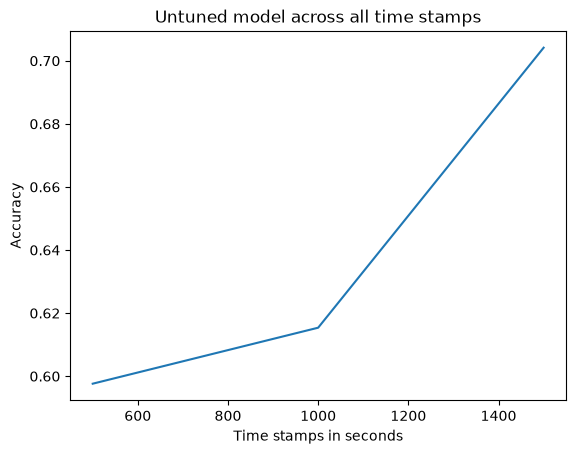

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(accuracies_df, x="Time stamps in seconds", y="Accuracy")
_ = plt.title("Untuned model across all time stamps")